
# 1 Introduction and Overview of Inference Deployment


This chapter mainly introduces the high-performance inference method, service deployment method and end-side deployment method of the PP-OCRv2 system. Through the study of this chapter, you can learn:

* Choose the appropriate predictive deployment method according to different scenarios
* Inference methods of PP-OCRv2 series models in different scenarios
* Inference deployment development methods of Paddle Inference, Paddle Serving, and Paddle Lite

## 1.1 Introduction

In the previous chapters, we obtained the trained model through the method of model training. When using it to predict, we first need to define the model, then load the trained model, and then preprocess the data Send it to the network for prediction and post-processing, and get the final result. Using this method to make predictions is convenient for debugging, but the prediction efficiency is relatively low.

In view of the above problems, for the trained model, there are generally the following two offline prediction methods.

1. Inference based on the training engine, that is, using the same set of engine as the training, it is convenient for debugging, which is convenient for us to quickly locate the problem and verify the correctness. Mostly Python language.
2. Based on the prediction engine inference, the trained model is transformed, and the parts that are not related to the inference are removed. Using this method can speed up the prediction. Most of them are Python language or C++.

The specific differences between the two are shown below.
<center>

|      | Inference based on training engine    | Inference based on prediction engine    |
|:------:|:------|:------|
| Features   |1. Use the same set of engine as training</br>2. The network model needs to be defined when inferencing</br>3. Not suitable for system integration| 1. The model needs to be converted, and the parts that are not related to inference are removed</br>2. * *There is no need to define a network model when inferencing**</br>3. Suitable for system integration|
| Programming language | More as Python                                     | Python or C++                     |
| Prediction step | 1. Define the network structure on the Python side</br>2. Prepare the input data</br>3. Load the training model</br>4. Perform prediction| 1. Prepare the input data</br>2. Load the model structure and model Parameters</br>3. Perform prediction|

</center>

In actual offline prediction deployment, it is more recommended to perform inference based on the prediction engine.

From the perspective of application scenarios, the flying paddle provides the following inference deployment solutions for different application scenarios.

<div align="center">
<img src="https://ai-studio-static-online.cdn.bcebos.com/d95a9b662f944af589cf3934b7012f54bfb1ef610c0447568712618fdb6216a2"  width = "1200" />
</div>
<center>Figure 1: Different deployment options for paddles</center>

Specifically, PaddleOCR provides three predictive deployment solutions for different application scenarios.

* Inference offline prediction. This method is mainly used in scenarios where the timeliness of the prediction response is not high, especially in scenes that require a large number of picture predictions. Such as document digitization, advertising information extraction, etc. Although the inference request cannot be responded to in time, there is no network delay, the calculation efficiency is relatively high, and the data security is high.
* Serving service deployment, this method is mainly used in scenarios that require high timeliness of predictive response, such as the API interface of commercial OCR, real-time photo translation, and topic shooting. Although this method can respond to inference demand in a timely manner, the network is time-consuming and expensive, GPU utilization is often low, and there are data security risks.
* Lite end-side deployment, this method mainly hopes to deploy the model to end-side devices such as mobile phones and robots, mainly considering the convenience of deployment and data security, such as ID card recognition in mobile APP, bank card recognition, and instrument monitoring in industrial application scenarios Recognition etc. This method is more sensitive to the size of the OCR model. Although there is no network delay and data security is high, the prediction efficiency is not high due to the limitation of computing power.

Based on PP-OCRv2, this chapter introduces the process of text detection, recognition, and system series prediction, inference and deployment.

## 1.2 Environmental preparation

To experience the content of this chapter, you need to download the PaddleOCR code first and install related dependencies. The specific commands are as follows.

In [1]:
!pwd

/home/loc/Workspace/ocr-exp


In [2]:
import os
# Download code
!git clone https://gitee.com/paddlepaddle/PaddleOCR.git
%cd PaddleOCR 
# Install and run the required whl package
!pip install -U pip
!pip install -r requirements.txt
# This library is needed in VQA tasks
!pip install paddlenlp==2.2.1

# Import some libraries
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import os

Cloning into 'PaddleOCR'...
remote: Enumerating objects: 45032, done.
remote: Counting objects: 100% (19411/19411), done.
remote: Compressing objects: 100% (6942/6942), done.
remote: Total 45032 (delta 14187), reused 17346 (delta 12332), pack-reused 25621
Receiving objects: 100% (45032/45032), 335.31 MiB | 1.99 MiB/s, done.
Resolving deltas: 100% (32048/32048), done.
Updating files: 100% (1618/1618), done.
/home/loc/Workspace/ocr-exp/PaddleOCR


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 1.0 MB/s eta 0:00:001.0 MB/s eta 0:00:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 726.4 kB/s eta 0:00:00m eta 0:00:010:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 2.2 MB/s eta 0:00:00m eta 0:00:010:00:010m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 504.1 kB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.0/298.0 kB 1.5 MB/s eta 0:00:001.7 MB/s eta 0:00:01
  Created wheel for jieba: filename=jieba-0.42.1-py3-none-any.whl size=19314458 sha256=9eb20d2904429e458a1dd3273b5dd4c90f29ba57a11bac3562d27200c406eacf
  Stored in directory: /home/loc/.cache/pip/wheels/10/a7/21/b0ced8222c9b5e1eae11b7d13d40d028786c5e57e4c604c5da
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size


# 2 Python Inference Based on Paddle Inference

## 2.1 Introduction

In the project, the inference performance of the model directly affects the cost of the project, so we hope that a model of a trained model can have a faster inference speed. The prediction is directly based on the training engine, and the model contains operators related to training, so **the efficiency is generally low**; and the model needs to be defined, which is **difficult to decouple from the training code**. Paddle Inference came into being. It is the native inference library of Flying Paddle, which acts on the server and the cloud to provide high-performance inference capabilities. Since the ability is directly based on the training operator of the flying paddle, Paddle Inference can universally support all models trained by the flying paddle.

Considering that everyone’s usage scenarios are very different, Paddle Inference has carried out in-depth adaptation and optimization for different platforms and different application scenarios, achieving high throughput and low latency, ensuring that the flying paddle model is ready to use on the server side, and is fast deploy.

This chapter mainly introduces the prediction inference process of **PP-OCRv2** based on Paddle Inference. For more introduction about Paddle Inference, please refer to: [Paddle Inference Introduction](https://paddleinference.paddlepaddle.org.cn/product_introduction/inference_intro.html).

When performing model inference based on Paddle Inference, there are generally the following steps.
<div align="center">
<img src="https://ai-studio-static-online.cdn.bcebos.com/18090cbc0733401caeb868f7bf7759436771ba71bce444a8a4ff5dbc5eece03c"  width = "600" />
</div>
<center>Figure 2: Paddle Inference process</center>

The PP-OCRv2 system includes three models: text detection, direction classifier, and text recognition. The following describes the inference process of these three models based on Paddle Inference.


## 2.2 PP-OCRv2 Text Detection Model Inference

In PaddleOCR, when inference is based on the text detection model,
- the parameter `image_dir` specifies the path of a single image or image collection,
- the parameter `det_model_dir` specifies the path of the detected `inference` model.

The following is the latest ultra-lightweight text detection model inference actual combat. For more models and usage methods, please refer to [Text Detection Prediction Tutorial](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.4/doc/doc_ch/inference_ppocr.md).

For more introduction to the hyperparameters of other algorithms, please refer to [PaddleOCR Inference related parameters introduction](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.4/doc/doc_ch/inference.md#%E5%85%AD%E5%8F%82%E6%95%B0%E8%A7%A3%E9%87%8A).


### 2.2.1 Prepare Data and Environment

At the very beginning, Paddle and the corresponding dependencies have been installed, and the environment here is ready.

The test sample data is under the `doc/imgs` folder, and part of the data is shown below.

00006737.jpg  00056221.jpg  00111002.jpg  1.jpg		japan_1.jpg
00009282.jpg  00057937.jpg  00207393.jpg  french_0.jpg	japan_2.jpg
00015504.jpg  00059985.jpg  11.jpg	  ger_1.jpg	korean_1.jpg
00018069.jpg  00077949.jpg  12.jpg	  ger_2.jpg	model_prod_flow_ch.png


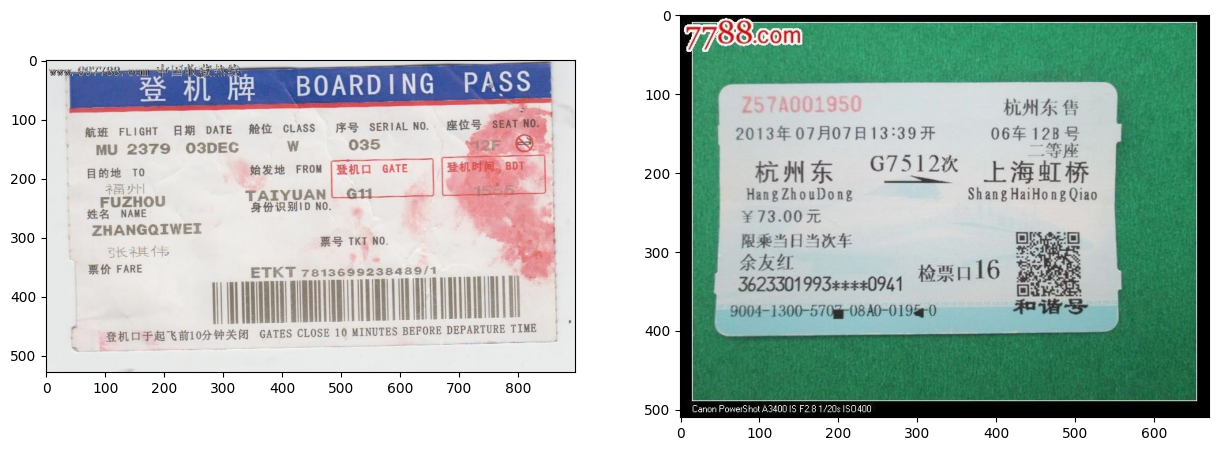

In [4]:
#View data
!ls doc/imgs/

# Choose 2 images to visualize
img1 = cv2.imread("doc/imgs/00006737.jpg")
img2 = cv2.imread("doc/imgs/00056221.jpg")
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(img1[:,:,::-1])
plt.subplot(1, 2, 2)
plt.imshow(img2[:,:,::-1])
plt.show()

### 2.2.2 Prepare the inference model

Download the inference model, unzip it, and place it under the `inference` directory.

In [5]:
# Download model
!mkdir inference
!cd inference && wget https://paddleocr.bj.bcebos.com/PP-OCRv2/chinese/ch_PP-OCRv2_det_infer.tar -O ch_PP-OCRv2_det_infer.tar && tar -xf ch_PP-OCRv2_det_infer.tar

--2023-01-04 00:43:58--  https://paddleocr.bj.bcebos.com/PP-OCRv2/chinese/ch_PP-OCRv2_det_infer.tar
Resolving paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)... 103.235.46.61, 2409:8c04:1001:1002:0:ff:b001:368a
Connecting to paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)|103.235.46.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3450880 (3,3M) [application/x-tar]
Saving to: ‘ch_PP-OCRv2_det_infer.tar’

ch_PP-OCRv2_det_inf 100%[===================>]   3,29M   828KB/s    in 5,4s    

2023-01-04 00:44:05 (622 KB/s) - ‘ch_PP-OCRv2_det_infer.tar’ saved [3450880/3450880]

/bin/bash: tree: command not found


In [6]:
!ls -h inference/ch_PP-OCRv2_det_infer

inference.pdiparams  inference.pdiparams.info  inference.pdmodel


**Note** If you want to **export the model you have trained and deploy it using Paddle Inference**, you can use the following command to convert the pre-trained model into an inference model using dynamic and static methods.

    # Derive inference model
    !python tools/export_model.py -c configs/det/ch_PP-OCRv2/ch_PP-OCRv2_det_cml.yml \
        -o Global.pretrained_model="./pretrain_models/ch_PP-OCRv2_det_distill_train/best_accuracy" \
        Global.save_inference_dir="./my_model"
    # The PP-OCRv2 detection model contains 3 sub-networks: teacher, student, and student 2. Therefore, when exporting, it contains 3 sub-files. In actual inference, one of the student networks can be used for inference.

### 2.2.3 A Preliminary Study of Text Detection Function

Let's first take a look at the predicted results of the loading inference model.

[2023/01/04 00:58:34] ppocr INFO: 00018069.jpg	[[[300.0, 250.0], [344.0, 250.0], [344.0, 266.0], [300.0, 266.0]], [[233.0, 250.0], [268.0, 250.0], [268.0, 266.0], [233.0, 266.0]], [[24.0, 250.0], [51.0, 250.0], [51.0, 266.0], [24.0, 266.0]], [[377.0, 250.0], [407.0, 247.0], [409.0, 266.0], [379.0, 266.0]], [[102.0, 248.0], [183.0, 248.0], [183.0, 266.0], [102.0, 266.0]], [[380.0, 232.0], [406.0, 232.0], [406.0, 248.0], [380.0, 248.0]], [[288.0, 230.0], [356.0, 230.0], [356.0, 248.0], [288.0, 248.0]], [[235.0, 232.0], [264.0, 232.0], [264.0, 248.0], [235.0, 248.0]], [[23.0, 232.0], [52.0, 232.0], [52.0, 248.0], [23.0, 248.0]], [[101.0, 229.0], [184.0, 229.0], [184.0, 248.0], [101.0, 248.0]], [[233.0, 213.0], [268.0, 213.0], [268.0, 228.0], [233.0, 228.0]], [[379.0, 212.0], [407.0, 212.0], [407.0, 230.0], [379.0, 230.0]], [[298.0, 209.0], [346.0, 212.0], [344.0, 232.0], [297.0, 229.0]], [[101.0, 207.0], [184.0, 210.0], [184.0, 232.0], [100.0, 229.0]], [[24.0, 212.0], [50.0, 212.0], [50.0

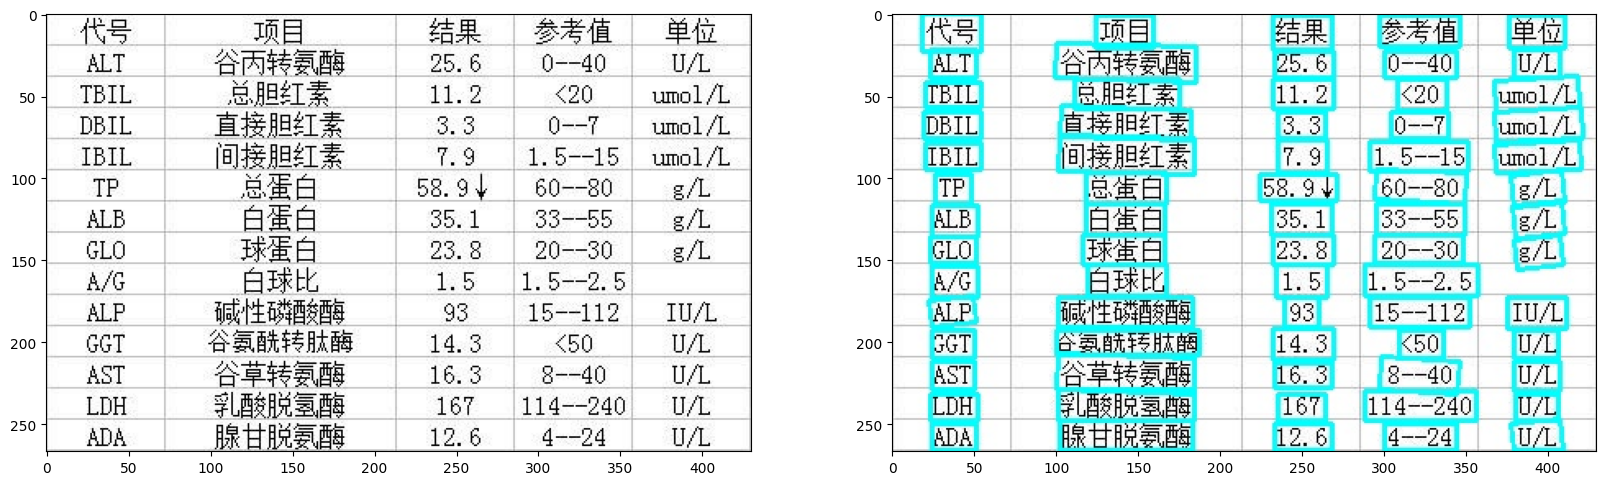

In [27]:
# Reference Code
# https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.4/tools/infer/predict_det.py
# prediction
!python tools/infer/predict_det.py --image_dir="./doc/imgs/00018069.jpg"\
--det_model_dir="./inference/ch_PP-OCRv3_det_infer" --use_gpu=False

# Read the image and display it, display the result
plt.figure(figsize=(20, 8))
img_ori = cv2.imread("./doc/imgs/00018069.jpg")
img_out = cv2.imread("./inference_results/det_res_00018069.jpg")
plt.subplot(1, 2, 1)
plt.imshow(img_ori[:,:,::-1])
plt.subplot(1, 2, 2)
plt.imshow(img_out[:,:,::-1])
plt.show()


The above completes the complete text detection process.

## 2.3 PP-OCRv2 - Directional Classifier Model Inference

Similarly, for the direction classifier model, we can also use the following commands to quickly experience its functions.

In [56]:
#Reference Code
# https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.4/tools/infer/predict_cls.py
# Download model
!cd inference && wget https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar -O ch_ppocr_mobile_v2.0_cls_infer.tar && tar -xf ch_ppocr_mobile_v2.0_cls_infer.tar

--2023-01-04 01:13:03--  https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar
Resolving paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)... 103.235.46.61, 2409:8c04:1001:1002:0:ff:b001:368a
Connecting to paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)|103.235.46.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2188800 (2,1M) [application/x-tar]
Saving to: ‘ch_ppocr_mobile_v2.0_cls_infer.tar’

ch_ppocr_mobile_v2. 100%[===================>]   2,09M   429KB/s    in 5,6s    

2023-01-04 01:13:10 (382 KB/s) - ‘ch_ppocr_mobile_v2.0_cls_infer.tar’ saved [2188800/2188800]

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'


[2023/01/04 01:13:39] ppocr INFO: Predicts of ./doc/imgs_words/ch/word_1.jpg:['0', 0.9998784]


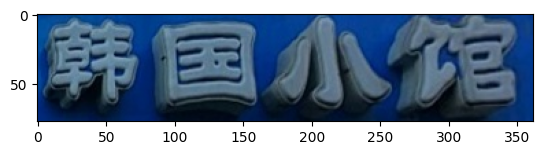

In [57]:
# predict
!python tools/infer/predict_cls.py \
    --image_dir="./doc/imgs_words/ch/word_1.jpg" \
    --cls_model_dir="./inference/ch_ppocr_mobile_v2.0_cls_infer" \
    --use_gpu=False
# Drawing
img = cv2.imread("./doc/imgs_words/ch/word_1.jpg")
plt.imshow(img[:,:,::-1])
plt.show()

Here we can also rotate the image 180 degrees to see the classification effect of the direction classifier.

The above completes the inference process of the complete direction classifier.


## 2.4 PP-OCRv2 - Text Recognition Model Inference

For the text recognition model, we can also use the following commands to quickly experience its functions.

In [59]:
# Download model
!cd inference && wget https://paddleocr.bj.bcebos.com/PP-OCRv2/chinese/ch_PP-OCRv2_rec_infer.tar -O ch_PP-OCRv2_rec_infer.tar &&  tar -xf ch_PP-OCRv2_rec_infer.tar

--2023-01-04 01:15:03--  https://paddleocr.bj.bcebos.com/PP-OCRv2/chinese/ch_PP-OCRv2_rec_infer.tar
Resolving paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)... 103.235.46.61, 2409:8c04:1001:1002:0:ff:b001:368a
Connecting to paddleocr.bj.bcebos.com (paddleocr.bj.bcebos.com)|103.235.46.61|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9041920 (8,6M) [application/x-tar]
Saving to: ‘ch_PP-OCRv2_rec_infer.tar’

ch_PP-OCRv2_rec_inf 100%[===================>]   8,62M  1,28MB/s    in 13s     

2023-01-04 01:15:16 (678 KB/s) - ‘ch_PP-OCRv2_rec_infer.tar’ saved [9041920/9041920]



[2023/01/04 01:17:07] ppocr INFO: In PP-OCRv3, rec_image_shape parameter defaults to '3, 48, 320', if you are using recognition model with PP-OCRv2 or an older version, please set --rec_image_shape='3,32,320
[2023/01/04 01:17:07] ppocr INFO: Predicts of subset/out.jpg:('122610119000', 0.7151519656181335)


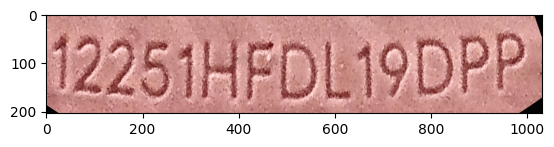

In [62]:
# Reference Code
# https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.4/tools/infer/predict_rec.py
# predict
!python tools/infer/predict_rec.py \
    --image_dir="subset/out.jpg" \
    --rec_model_dir="./inference/ch_PP-OCRv2_rec_infer" \
    --use_gpu=False

# Read the image and display
img = cv2.imread("subset/out.jpg")
plt.imshow(img[:,:,::-1])
plt.show()

## 2.5 PP-OCRv2 - System Series Prediction and Inference

The previous content introduced you to the separate inference process of detection, direction classifier, and recognition model in the PP-OCRv2 system. In order to facilitate everyone's end-to-end use, we connected these three modules in series to form the PP-OCRv2 system, and provided the corresponding prediction script.

When performing system inference of PP-OCRv2, you need to specify the path of a single image or image collection through the parameter `image_dir`, and the parameters `det_model_dir`, `cls_model_dir` and `rec_model_dir` to specify the `inference` for detection, direction classification, and recognition, respectively Model path. The parameter `use_angle_cls` is used to control whether to enable the direction classification model. `use_mp` indicates whether to use multiple processes. `total_process_num` indicates the number of processes when using multiple processes.


Taking the image file `./doc/imgs/00018069.jpg` as an example, the predicted original image is as follows.

<div align="center">
<img src="https://ai-studio-static-online.cdn.bcebos.com/5b00f13167014bb1b5b94af65c287509e645043507504ae99f912832e7998c5f"  width = "600" />
</div>
<center>Figure 3: The original image</center>


If you use a direction classifier for tandem prediction, you can use the following command to make predictions.
The series prediction is implemented by the `TextSystem` class, and its specific implementation process and function are defined as follows.